In [577]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import illustris_python as il
import pickle
from scipy.optimize import curve_fit
import scipy

In [578]:
odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/logM11-11.5.pickle", "rb") as f:
    Pk_mean11 = pickle.load(f)
    Pk11 = pickle.load(f)
print("shotnoise", Pk11.attrs["shotnoise"])

shotnoise 105.90268152292435


In [579]:
odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/logM11-11.1.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk110 = pickle.load(f)
print("shotnoise", Pk110.attrs["shotnoise"])

shotnoise 286.3949289238728


In [580]:
odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/logM11.4-11.5.pickle", "rb") as f:
    Pk_mean114 = pickle.load(f)
    Pk114 = pickle.load(f)
print("shotnoise", Pk110.attrs["shotnoise"])

shotnoise 286.3949289238728


In [581]:
from nbodykit.lab import cosmology as n_cosmology
#c      = n_cosmology.Planck15
#n_cosmology.P_k_max=100
c = n_cosmology.Cosmology(h=0.67556, T0_cmb=2.7255, Omega0_b=0.0482754208891869, Omega0_cdm=0.26377065934278865, N_ur=None, m_ncdm=[0.06], P_k_max=100.0, P_z_max=100.0, gauge='synchronous', n_s=0.9667, nonlinear=False, verbose=False)
Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')
Pnl = n_cosmology.power.halofit.HalofitPower(c, redshift=1.5) 
cf_lin = n_cosmology.CorrelationFunction(Plin)
cf_nl = n_cosmology.CorrelationFunction(Pnl)

In [582]:
def kernel_lin(ks, R=1, nbins=100):
    results = []
    r = np.linspace(0, R, nbins)
    xi = cf_lin(r)
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

In [670]:
def kernel_NL(ks, R=1, nbins=100):
    results = []
    r = np.linspace(0, R, nbins)
    xi = cf_nl(r)
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

In [583]:
def W_R(k, R=1):
    return 3 * (np.sin(k*R) - k*R*np.cos(k*R))/(k*R)**3

In [584]:
def scale_dependent_bias(logk, a, b, c, d, logk0):
    bias_k = a + b*(logk-logk0) + c*(logk-logk0)**2 + d*(logk-logk0)**3
    return bias_k

In [672]:
def fit_pow(logk, a=1, b=1, c=0.01, d=0.1, logk0=-0.5, R=1, kernel_type="lin"):
    bias_k = scale_dependent_bias(logk, a, b, c, d, logk0)

    #mask = logk < logk0
    #result[mask] = a
    if kernel_type == "lin":
        kernel = kernel_lin(10**logk, R=R)
    elif kernel_type == "new":
        kernel = kernel_new(10**logk, R=R)
    elif kernel_type == "nl":
        kernel = kernel_NL(10**logk, R=R)
    
    result1 = bias_k*Plin(10**logk) - bias_k*kernel - ((4*np.pi*R**3)/3)*W_R(10**logk, R)
    
    return result1

In [586]:
def fit_pow_lin(logk, a=1, b=1, c=0.01, d=0.1, logk0=-0.5, R=1):
    return fit_pow(logk, a, b, c, d, logk0, R, kernel_type="lin")

In [674]:
def fit_pow_NL(logk, a=1, b=1, c=0.01, d=0.1, logk0=-0.5, R=1):
    return fit_pow(logk, a, b, c, d, logk0, R, kernel_type="nl")

In [587]:
def fit_pow_lin_fixed(logk, a=1,  c=0.01, logk0=-0.5, R=1):
    return fit_pow(logk, a, 0, c, 0, logk0, R, kernel_type="lin")

In [588]:
def fit_pow_lin_fixed_d(logk, a=1, b=1, c=0.01, logk0=-0.5, R=1):
    return fit_pow(logk, a, b, c, 0, logk0, R, kernel_type="lin")

In [589]:
def fit_pow_lin_fixed_coef(logk, a=1,  c=0.01, logk0=-0.5, R=1):
    return kcoef(10**logk)*fit_pow(logk, a, 0, c, 0, logk0, R, kernel_type="lin")

In [590]:
def fit_pow_new(logk, a=1, b=1, c=0.01, d=0.1, logk0=-0.5, R=1):
    return fit_pow(logk, a, b, c, d, logk0, R, kernel_type="new")

(1.0, 5.0)

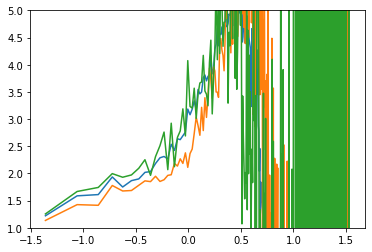

In [591]:
plt.plot(np.log10(Pk11["k"]),(Pk11["power"].real-Pk11.attrs["shotnoise"])/Plin(Pk11["k"]))
plt.plot(np.log10(Pk110["k"]),(Pk110["power"].real-Pk110.attrs["shotnoise"])/Plin(Pk11["k"]))

plt.plot(np.log10(Pk114["k"]),(Pk114["power"].real-Pk114.attrs["shotnoise"])/Plin(Pk11["k"]))
plt.ylim(1,5)

In [599]:
def optimise_fit(Pk, logM=12, logk_scale=-0.5):
    #mask = (np.log10(Pk["k"]) > logk_scale) 
    mask = (np.log10(Pk["k"]) > -1.5) & (np.log10(Pk["k"]) < 1.3)
    logk1 = np.log10(Pk["k"])[mask]
    pow1 = (Pk["power"].real-Pk.attrs["shotnoise"])[mask]
    
    logk0 = -1.5
    if logM == 12:
        bias1 = 1
        R1 = 0.7
        Rmin = 0.5
        Rmax = 1
        bias_min = 0.9
        bias_max = 1.1
        
        a1 = 2.5
        b1 = 0
        c1 = 2
        d1 = 0
    elif logM == 11:
        R1 = 0.2
        Rmin = 0.1
        Rmax = 0.6
        
        a1 = 1
        b1 = 0
        c1 = 1
        d1 = 0
    
    err = 2*pow1/np.sqrt(nmodes[mask])
    mask_err = np.log10(Pk["k"])[mask] > 0.4
    err[mask_err] = 500*err[mask_err]
    
    #weighting_mask = (np.log10(Pk["k"][mask]) > 0.7) & (np.log10(Pk["k"][mask]) < 1.3)
    #weighting = np.ones(len(Pk["k"][mask]))
    #weighting = np.where(weighting_mask,  weighting, 100)
    weighting = Pk["power"].real[mask]
    #p0_1 = [a1, b1, c1, d1,logk0,bias1,R1]
    #bounds1=([-2, -2, -2,-2, -2, bias_min, Rmin], [4, 4, 4,2, 1, bias_max,Rmax])
    #p0_1 = [a1, b1, c1, d1,logk0,R1]
    #bounds1=([0, 0, 0,-0.1, -1.6, Rmin], [4, 0.1, 6,0.1, -1.4, Rmax])
    
    p0_1 = [a1,  c1, logk0,R1]
    bounds1=([0,  0, -3, Rmin], [4,  6, -1, Rmax])
    #pop_fit1, pcov1 = curve_fit(fit_pow_lin, logk1,pow1,maxfev = 4000,p0=p0_1, bounds=bounds1, sigma=err, absolute_sigma=True)

    #pop_fit1, pcov1 = curve_fit(fit_pow_lin_fixed, logk1,pow1,maxfev = 4000,p0=p0_1, bounds=bounds1, sigma=err, absolute_sigma=True)
    pop_fit1, pcov1 = curve_fit(fit_pow_lin_fixed, logk1,pow1,maxfev = 4000,p0=p0_1, bounds=bounds1, sigma=None)
    
    #pop_fit1, pcov1 = curve_fit(fit_pow_lin_fixed_coef, logk1,kcoef(10**logk1)*pow1,maxfev = 4000,p0=p0_1, bounds=bounds1, sigma=None)
    
    
    return pop_fit1

In [600]:
pop_fit12 = optimise_fit(Pk11, logM=11)
print(pop_fit12)

[ 0.56253235  0.25003494 -3.          0.20148702]


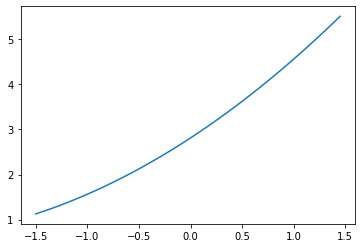

In [635]:
params = [pop_fit12[0], 0, pop_fit12[1], 0, pop_fit12[2], pop_fit12[3],]
b = scale_dependent_bias(logks, *params[:-1])
plt.plot(logks,b)

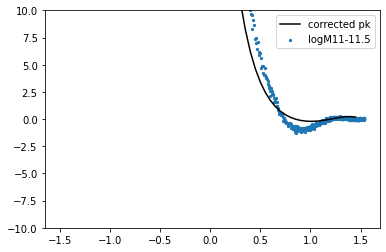

In [604]:

logks = np.arange(-1.5,1.5, 0.05)
plt.scatter(np.log10(Pk11["k"]),Pk11["power"].real-Pk11.attrs["shotnoise"], s=5, label="logM11-11.5")
plt.plot(logks, fit_pow_lin(logks, *params), label="corrected pk", c="k")

plt.ylim(-10,10)
plt.legend()

(-2.0, 10.0)

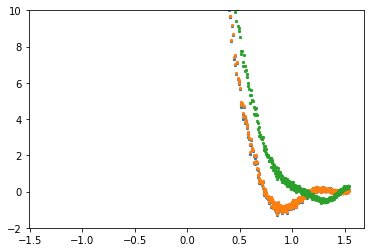

In [625]:
plt.scatter(np.log10(Pk11["k"]),Pk11["power"].real-Pk11.attrs["shotnoise"], s=5, label="logM11-11.5")
plt.scatter(np.log10(Pk11["k"]),Pk11["power"].real-Pk11.attrs["shotnoise"]+W_term, s=5, label="logM11-11.5")
plt.scatter(np.log10(Pk11["k"]),Pk11["power"].real-Pk11.attrs["shotnoise"]+10*kernel, s=5, label="logM11-11.5")

plt.ylim(-2,10)

In [626]:
def kcoef(ks):
    return ks**3/(2*np.pi**2)

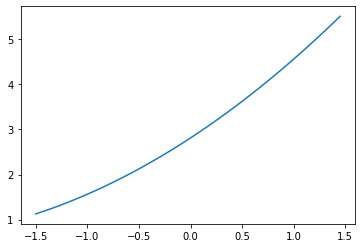

In [636]:
plt.plot(logks,b)

In [649]:
R = 0.25
logk = np.log10(Pk11["k"])
W_term =  ((4*np.pi*R**3)/3)*W_R(10**logk, R)

In [661]:
from colossus.cosmology import cosmology as colossus_cosmology
cosmo_colossus = colossus_cosmology.setCosmology(cosmo_name="planck15")
new_pk_colossus = cosmo_colossus.matterPowerSpectrum(k=10**logks,z=1.5, path="new_pk_lin.txt")
r_arr = np.arange(0.01, 1, 0.01)
cf_new = cosmo_colossus.correlationFunction(r_arr, z=1.5)

In [662]:

logks = np.arange(-1.5, 1.5, 0.1)
bias = scale_dependent_bias(logks, *params[:-1])
new_pk_lin = bias*Plin(10**logks)

In [663]:
with open("new_pk_lin.txt", "w") as f:
    for i, logk in enumerate(logks):
        print(logk, new_pk_lin[i], file=f)

In [664]:
def kernel_new(ks, R=1, nbins=100):
    
    cosmo_colossus = colossus_cosmology.setCosmology(cosmo_name="planck15")
    new_pk_colossus = cosmo_colossus.matterPowerSpectrum(k=10**logks,z=1.5, path="new_pk_lin.txt")
    
    results = []
    r = np.linspace(1e-3, R, nbins)
    cf_new = cosmo_colossus.correlationFunction(r, z=1.5)
    xi = cf_new
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

In [665]:
def fit_pow_new(logk, a=1, b=1, c=0.01, d=0.1, logk0=-0.5, R=1):
    return fit_pow(logk, a, b, c, d, logk0, R, kernel_type="new")

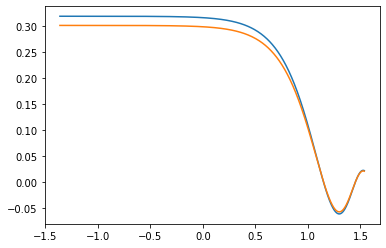

In [666]:
logk1 = np.log10(Pk11["k"])
plt.plot(logk1, kernel_lin(10**logk1, R))
plt.plot(logk1, kernel_new(10**logk1, R))

In [650]:
kernel = kernel_lin(10**logk, R)

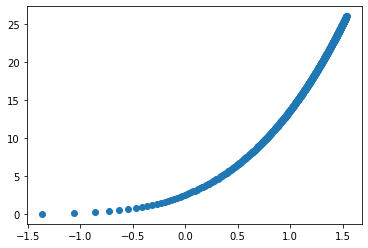

In [651]:
b1 = scale_dependent_bias(np.log10(Pk11["k"]), *params[:-1])

plt.scatter(np.log10(Pk11["k"]), kcoef(Pk11["k"])*b1*Plin(Pk11["k"]))

(-2.0, 1.0)

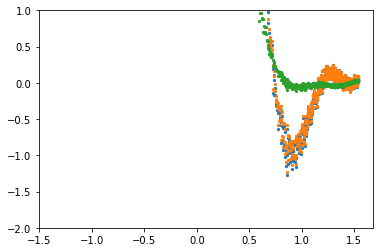

In [676]:
plt.scatter(np.log10(Pk11["k"]),(Pk11["power"].real-Pk11.attrs["shotnoise"]), s=5, label="logM11-11.5")
plt.scatter(np.log10(Pk11["k"]),(Pk11["power"].real-Pk11.attrs["shotnoise"]+W_term), s=5, label="logM11-11.5")
plt.scatter(np.log10(Pk11["k"]),(Pk11["power"].real-Pk11.attrs["shotnoise"]+(b1*kernel)+W_term)/b1, s=5, label="logM11-11.5")
#ker_nl = kernel_lin(Pk11["k"], R)
#plt.scatter(np.log10(Pk11["k"]),(Pk11["power"].real-Pk11.attrs["shotnoise"]+ker_nl+W_term), s=5, label="logM11-11.5")

plt.ylim(-2,1)


(-2.0, 100.0)

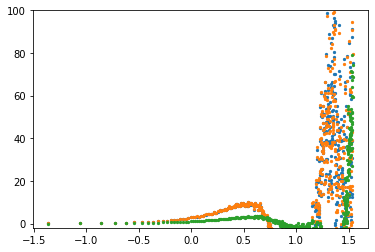

In [648]:
plt.scatter(np.log10(Pk11["k"]),kcoef(Pk11["k"])*(Pk11["power"].real-Pk11.attrs["shotnoise"]), s=5, label="logM11-11.5")
plt.scatter(np.log10(Pk11["k"]),kcoef(Pk11["k"])*(Pk11["power"].real-Pk11.attrs["shotnoise"]+W_term), s=5, label="logM11-11.5")
plt.scatter(np.log10(Pk11["k"]),kcoef(Pk11["k"])*(Pk11["power"].real-Pk11.attrs["shotnoise"]+(b1*kernel)+W_term)/b1, s=5, label="logM11-11.5")

plt.ylim(-2,100)


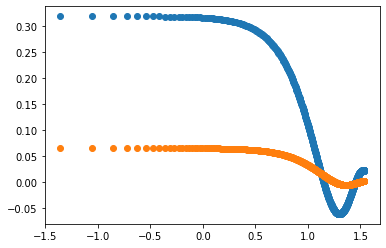

In [621]:
plt.scatter(np.log10(Pk11["k"]),kernel)

plt.scatter(np.log10(Pk11["k"]),W_term)